c:\Users\BUI QUANG HUNG\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Đã xác định cột thời gian là: 'local_time'

--- KẾT QUẢ ADF TEST ---
p-value: 0.0000
Kết luận: Chuỗi đã dừng.


21:05:28 - cmdstanpy - INFO - Chain [1] start processing
21:05:54 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\BUI QUANG HUNG\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


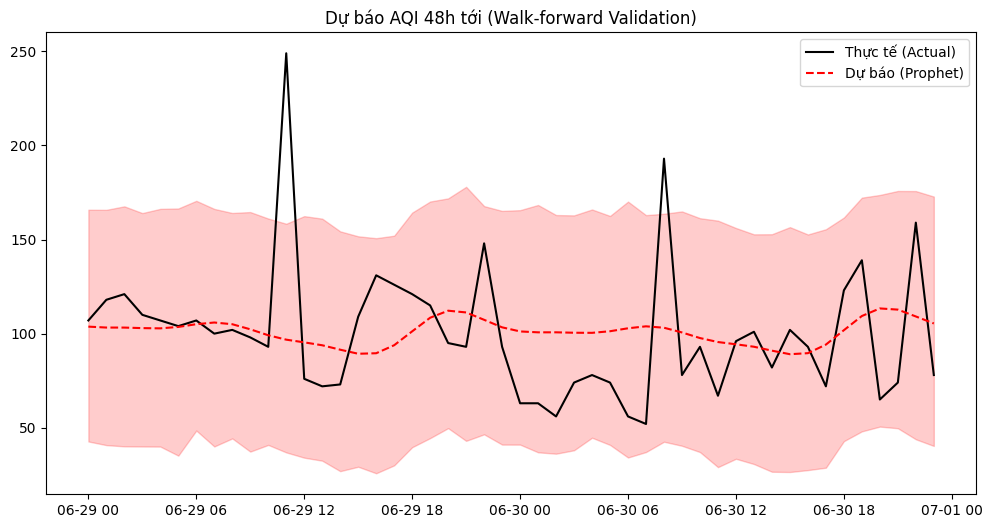

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load dữ liệu
df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')

# --- SỬA LỖI KEYERROR: Tự động tìm cột thời gian ---
# Chuyển tên cột về chữ thường để dễ tìm
df.columns = df.columns.str.strip().str.lower()

# Tìm xem cột nào là thời gian (thường chứa chữ 'date' hoặc 'time')
date_col = [c for c in df.columns if 'date' in c or 'time' in c]
if date_col:
    df = df.rename(columns={date_col[0]: 'datetime'})
    print(f"Đã xác định cột thời gian là: '{date_col[0]}'")
else:
    # Nếu không tìm thấy, ép cột đầu tiên làm datetime (giả định cột 0 là ngày)
    df.rename(columns={df.columns[0]: 'datetime'}, inplace=True)

df['datetime'] = pd.to_datetime(df['datetime'])

# --- NHIỆM VỤ 1: ADF TEST ---
print("\n--- KẾT QUẢ ADF TEST ---")
# Đảm bảo cột AQI cũng viết thường
df.columns = df.columns.str.strip().str.lower()
result = adfuller(df['aqi'].dropna())
print(f'p-value: {result[1]:.4f}')

if result[1] > 0.05:
    print("Kết luận: Chuỗi không dừng. Cần Differencing.")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    plot_acf(df['aqi'].diff().dropna(), ax=axes[0])
    plot_pacf(df['aqi'].diff().dropna(), ax=axes[1])
    plt.show()
else:
    print("Kết luận: Chuỗi đã dừng.")

# --- NHIỆM VỤ 2: PROPHET FORECASTING ---
# Chuẩn bị dữ liệu ds, y
df_p = df[['datetime', 'aqi']].rename(columns={'datetime': 'ds', 'aqi': 'y'})

# Chia dữ liệu Walk-forward (48h cuối làm Test)
train = df_p.iloc[:-48]
test = df_p.iloc[-48:]

# Khởi tạo model (chạy hơi lâu một chút nhé)
model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(train)

# Dự báo 48h
future = model.make_future_dataframe(periods=48, freq='H')
forecast = model.predict(future)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(test['ds'], test['y'], label='Thực tế (Actual)', color='black')
plt.plot(forecast['ds'].iloc[-48:], forecast['yhat'].iloc[-48:], label='Dự báo (Prophet)', color='red', linestyle='--')
plt.fill_between(forecast['ds'].iloc[-48:], 
                 forecast['yhat_lower'].iloc[-48:], 
                 forecast['yhat_upper'].iloc[-48:], alpha=0.2, color='red')
plt.title('Dự báo AQI 48h tới (Walk-forward Validation)')
plt.legend()
plt.show()

In [2]:

eval_df = test.copy()
eval_df['pred'] = forecast['yhat'].iloc[-48:].values

# Lấy lại thông tin mùa (season) từ dữ liệu gốc
eval_df['season'] = df['season'].iloc[-48:].values
eval_df['hour'] = eval_df['ds'].dt.hour

# 2. Tính RMSE theo Mùa
rmse_season = eval_df.groupby('season').apply(
    lambda x: np.sqrt(mean_squared_error(x['y'], x['pred']))
)

# 3. Tính RMSE theo Khung giờ (Giờ cao điểm vs Bình thường)
eval_df['time_slot'] = eval_df['hour'].apply(
    lambda x: 'Rush Hour' if (7 <= x <= 9 or 17 <= x <= 19) else 'Normal'
)
rmse_time = eval_df.groupby('time_slot').apply(
    lambda x: np.sqrt(mean_squared_error(x['y'], x['pred']))
)

# --- IN BÁO CÁO KẾT QUẢ ---
print("\n" + "="*45)
print("🔍 BÁO CÁO TÍNH CÔNG BẰNG (FAIRNESS REPORT)")
print("="*45)

print("\n[1] Sai số RMSE theo Mùa:")
print(rmse_season)

print("\n[2] Sai số RMSE theo Khung giờ:")
print(rmse_time)

# Kiểm tra Bias tự động
avg_rmse = rmse_season.mean()
print("\n" + "-"*45)
bias_detected = False
for s, r in rmse_season.items():
    if r > avg_rmse * 1.2:
        print(f"⚠️ PHÁT HIỆN BIAS: Model dự báo kém tại mùa {s.upper()}")
        print(f"   (Sai số cao hơn trung bình {((r/avg_rmse)-1)*100:.1f}%)")
        bias_detected = True

if not bias_detected:
    print("✅ KẾT LUẬN: Model đạt tính công bằng tốt giữa các mùa.")
else:
    print("\n💡 Đề xuất: Cần bổ sung dữ liệu hoặc train riêng cho các nhóm bị lệch.")
print("="*45)


🔍 BÁO CÁO TÍNH CÔNG BẰNG (FAIRNESS REPORT)

[1] Sai số RMSE theo Mùa:
season
2    35.764375
dtype: float64

[2] Sai số RMSE theo Khung giờ:
time_slot
Normal       36.043604
Rush Hour    34.913293
dtype: float64

---------------------------------------------
✅ KẾT LUẬN: Model đạt tính công bằng tốt giữa các mùa.


C:\Users\BUI QUANG HUNG\AppData\Local\Temp\ipykernel_4804\54258845.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_season = eval_df.groupby('season').apply(
C:\Users\BUI QUANG HUNG\AppData\Local\Temp\ipykernel_4804\54258845.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_time = eval_df.groupby('time_slot').apply(
